<a href="https://colab.research.google.com/github/joserafaeljordao/LEA2026/blob/main/RNN_serie_sunspot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import statsmodels.api as sm

# Introdução

O banco de dados utilizado neste trabalho corresponde à série anual de atividade solar disponibilizada no pacote statsmodels do Python.
Na documentação do pacote, essa base é descrita como uma série anual de manchas solares no período de 1700 a 2008, com 309 observações, tendo como variável principal SUNACTIVITY, que representa o número de manchas solares em cada ano. A origem informada pelo próprio statsmodels é o National Geophysical Data Center (NGDC), e a série é disponibilizada em domínio público.
(https://www.statsmodels.org/dev/datasets/generated/sunspots.html)

As manchas solares são regiões temporariamente mais escuras da superfície do Sol, associadas à intensa atividade magnética, sendo amplamente utilizadas como um indicador da variabilidade da atividade solar ao longo do tempo. Por esse motivo, séries históricas de manchas solares são frequentemente empregadas em estudos de modelagem temporal, previsão e análise de ciclos solares. O repositório oficial moderno do índice de manchas solares é o WDC-SILSO, mantido pelo Royal Observatory of Belgium, que descreve essa série como um dos principais indicadores de longo prazo da atividade solar.
(https://www.sidc.be/SILSO/home)

Nesse contexto, a utilização dessa base é adequada para a proposta deste estudo, pois se trata de uma série temporal longa, anual e com forte dependência temporal, características que favorecem a aplicação de métodos estatísticos e computacionais voltados à identificação de padrões e à realização de previsões. Além disso, a extensão histórica da série permite analisar diferentes fases do ciclo solar, incluindo períodos de baixa e alta atividade, o que torna o conjunto de dados particularmente útil para avaliar o desempenho preditivo dos modelos considerados.

# Leitura e análise descritiva dos dados

In [ ]:

torch.manual_seed(42)

df = sm.datasets.sunspots.load_pandas().data

anos = df["YEAR"].values
serie = df["SUNACTIVITY"].values.astype(np.float32)

print("Tamanho da série:", len(serie))
print(df.head())

Tamanho da série: 309
     YEAR  SUNACTIVITY
0  1700.0          5.0
1  1701.0         11.0
2  1702.0         16.0
3  1703.0         23.0
4  1704.0         36.0


 A seguir, apresentamos o gráfico da série e os gráficos da função de autocorrelação (ACF) e autocorrelação parcial (PACF)

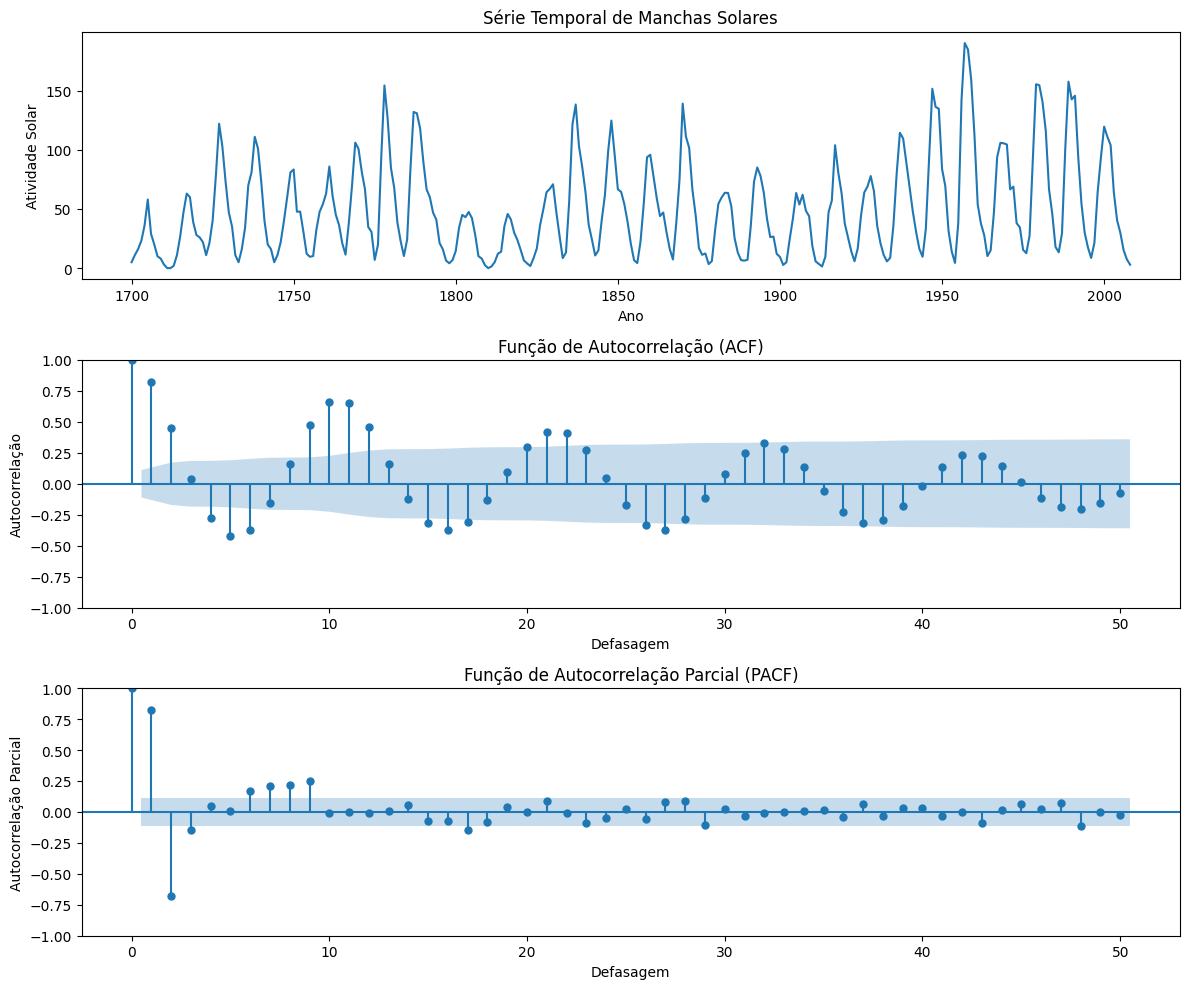

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot da série temporal
axes[0].plot(anos, serie)
axes[0].set_title('Série Temporal de Manchas Solares')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Atividade Solar')

# Plot da ACF
sm.graphics.tsa.plot_acf(serie, lags=50, ax=axes[1])
axes[1].set_title('Função de Autocorrelação (ACF)')
axes[1].set_xlabel('Defasagem')
axes[1].set_ylabel('Autocorrelação')

# Plot da PACF
sm.graphics.tsa.plot_pacf(serie, lags=50, ax=axes[2], method='ywm')
axes[2].set_title('Função de Autocorrelação Parcial (PACF)')
axes[2].set_xlabel('Defasagem')
axes[2].set_ylabel('Autocorrelação Parcial')

plt.tight_layout()
plt.show()

Para auxiliar no treinamento da rede neural, vamos normalizar a série e formatar os dados em janelas históricas, assim permitindo o aprendizado padrões temporais mais complexos e melhorar a generalização.

Com o gráfico da ACF, vemos que até a defasagem 12, existe certa correlação entre as observações, portanto, vamos usar janelas de 12 anos.

# Preparar a série e dividir os dados em treino e teste

In [ ]:
media = serie.mean()
desvio = serie.std()

serie_norm = (serie - media) / desvio


In [ ]:
X = []
y = []
janela = 12

for i in range(len(serie) - janela - 1):
   X.append(serie_norm[i:i+janela])
   y.append(serie_norm[i+janela])


X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (296, 12)
Shape de y : (296,)


Agora vamos separar os dados em treino e teste e fazer a conversão para tensores.

In [ ]:
n_treino = int(0.7 * len(X))

X_train = X[:n_treino]
X_test  = X[n_treino:]

y_train = y[:n_treino]
y_test  = y[n_treino:]

anos_alvo = anos[janela : janela + len(y)]
anos_train = anos_alvo[:n_treino]
anos_test  = anos_alvo[n_treino:]

X_train = torch.tensor(X_train).unsqueeze(-1)
X_test  = torch.tensor(X_test).unsqueeze(-1)

y_train = torch.tensor(y_train).unsqueeze(-1)
y_test  = torch.tensor(y_test).unsqueeze(-1)

print("Shape de X_train :", X_train.shape)
print("Shape de y_train :", y_train.shape)

Shape de X_train : torch.Size([207, 12, 1])
Shape de y_train : torch.Size([207, 1])


# RNN

A RNN usada contém 3 camadas com 3 neurônios cada.

O modelo foi capaz de capturar a variação dos dados de forma satisfatória. Outros modelos foram testados, porém, apenas o melhor foi apresentado. Apesar de outros modelos apresentarem EQM menor no conjunto de treino, não obtiveram boa generalização para o conjunto de teste. Por isso, optamos por proseguir com o modelo apresentado.

In [ ]:
class ModeloRNN(nn.Module):
    def __init__(self, hidden_size=3):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_size,num_layers=3,
            batch_first=True
        )

        self.linear = nn.Linear(hidden_size, 1)
    def forward(self, x):

        saida, h_n = self.rnn(x)

        ultimo_passo = saida[:, -1, :]

        previsao = self.linear(ultimo_passo)
        return previsao

modelo = ModeloRNN()

In [ ]:
criterio = nn.MSELoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.01)
epocas = 500
historico_loss = []

for epoca in range(epocas):
    modelo.train()

    otimizador.zero_grad()

    previsoes = modelo(X_train)
    loss = criterio(previsoes, y_train)

    loss.backward()
    otimizador.step()

    historico_loss.append(loss.item())

    if (epoca + 1) % 50 == 0:
        print(f"Época {epoca+1}/{epocas} - Loss: {loss.item():.4f}")


Época 50/500 - Loss: 0.1649
Época 100/500 - Loss: 0.0922
Época 150/500 - Loss: 0.0783
Época 200/500 - Loss: 0.0721
Época 250/500 - Loss: 0.0699
Época 300/500 - Loss: 0.0677
Época 350/500 - Loss: 0.0660
Época 400/500 - Loss: 0.0659
Época 450/500 - Loss: 0.0624
Época 500/500 - Loss: 0.0615


# Avaliação do ajuste

In [ ]:
modelo.eval()

with torch.no_grad():
    pred_train = modelo(X_train).squeeze().numpy()
    pred_test = modelo(X_test).squeeze().numpy()

pred_train = pred_train * desvio + media
pred_test  = pred_test * desvio + media

y_train_real = y_train.squeeze().numpy() * desvio + media
y_test_real  = y_test.squeeze().numpy() * desvio + media

rmse_train = np.sqrt(np.mean((pred_train - y_train_real)**2))
rmse_test  = np.sqrt(np.mean((pred_test - y_test_real)**2))

print(f"RMSE treino: {rmse_train:.2f}")
print(f"RMSE teste: {rmse_test:.2f}")



RMSE treino: 10.05
RMSE teste: 16.44


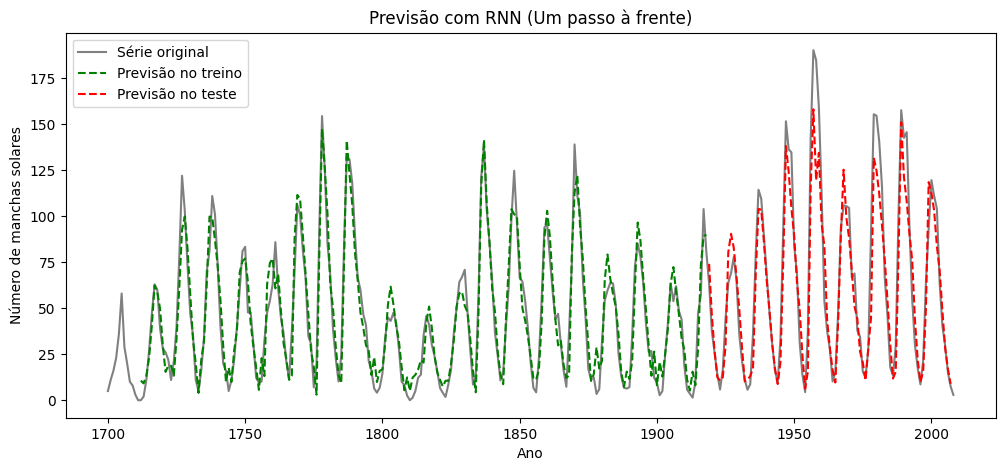

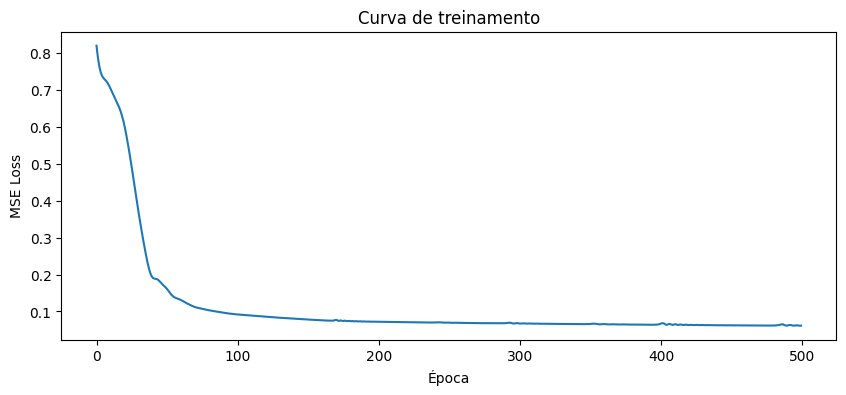

In [ ]:

plt.figure(figsize=(12, 5))
plt.plot(anos, serie, label="Série original", color='gray')

# Plotando as previsões de treino (um passo à frente)
plt.plot(anos_train, pred_train, label="Previsão no treino", color='green', linestyle='--')

# Plotando as previsões de teste (um passo à frente)
plt.plot(anos_test, pred_test, label="Previsão no teste", color='red', linestyle='--')

plt.xlabel("Ano")
plt.ylabel("Número de manchas solares")
plt.title("Previsão com RNN (Um passo à frente)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(historico_loss)
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.title("Curva de treinamento")
plt.show()

# Avalição do poder preditivo

Para avaliar a capacidade preditiva do modelo, serão realizadas previsões para observações que não estão presentes no banco de dados utilizado no ajuste. A predição será conduzida de forma iterativa, isto é, cada valor predito será utilizado como entrada para a previsão seguinte. Como consequência, a incerteza associada às previsões tende a se acumular ao longo do horizonte temporal, de modo que o desvio padrão aumenta conforme a previsão se estende para períodos mais distantes.

In [ ]:
current_window_norm = serie_norm[-janela:]
last_original_year = anos[-1]
future_anos = np.arange(last_original_year + 1, 2024 + 1, 1)

In [ ]:
future_predictions = []

modelo.eval()

with torch.no_grad():
    for _ in future_anos:
        input_tensor = torch.tensor(current_window_norm).unsqueeze(0).unsqueeze(-1)

        predicted_norm = modelo(input_tensor).squeeze().item()

        predicted_value = predicted_norm * desvio + media

        future_predictions.append(predicted_value)

        current_window_norm = np.append(current_window_norm[1:], predicted_norm).astype(np.float32)


In [ ]:
print("\n--- Sumário das Previsões Futuras (até 2024) ---")
for year, prediction in zip(future_anos, future_predictions):
    print(f"Ano: {int(year)}, Previsão de Atividade Solar: {prediction:.2f}")


--- Sumário das Previsões Futuras (até 2024) ---
Ano: 2009, Previsão de Atividade Solar: 10.66
Ano: 2010, Previsão de Atividade Solar: 27.25
Ano: 2011, Previsão de Atividade Solar: 45.39
Ano: 2012, Previsão de Atividade Solar: 70.78
Ano: 2013, Previsão de Atividade Solar: 73.48
Ano: 2014, Previsão de Atividade Solar: 66.89
Ano: 2015, Previsão de Atividade Solar: 54.32
Ano: 2016, Previsão de Atividade Solar: 36.60
Ano: 2017, Previsão de Atividade Solar: 21.77
Ano: 2018, Previsão de Atividade Solar: 11.00
Ano: 2019, Previsão de Atividade Solar: 10.59
Ano: 2020, Previsão de Atividade Solar: 20.35
Ano: 2021, Previsão de Atividade Solar: 32.24
Ano: 2022, Previsão de Atividade Solar: 55.67
Ano: 2023, Previsão de Atividade Solar: 78.66
Ano: 2024, Previsão de Atividade Solar: 83.35


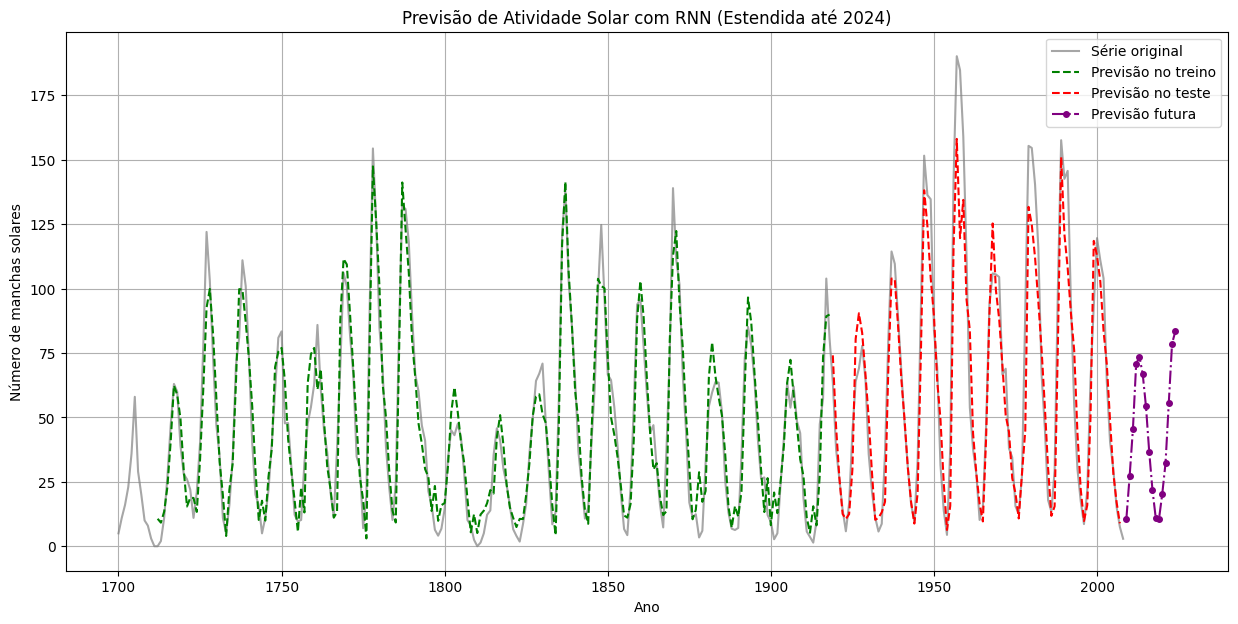

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(anos, serie, label="Série original", color='gray', alpha=0.7)

# Plotando as previsões de treino (um passo à frente)
plt.plot(anos_train, pred_train, label="Previsão no treino", color='green', linestyle='--')

# Plotando as previsões de teste (um passo à frente)
plt.plot(anos_test, pred_test, label="Previsão no teste", color='red', linestyle='--')

# Plotando as previsões futuras
plt.plot(future_anos, future_predictions, label="Previsão futura", color='purple', linestyle='-.', marker='o', markersize=4)

plt.xlabel("Ano")
plt.ylabel("Número de manchas solares")
plt.title("Previsão de Atividade Solar com RNN (Estendida até 2024)")
plt.legend()
plt.grid(True)
plt.show()

# Preparar os dados reais de 2009 - 2024 e calcular o EQM

In [ ]:
import pandas as pd

url = "https://www.sidc.be/silso/DATA/SN_y_tot_V2.0.csv"

df = pd.read_csv(
    url,
    sep=";",
    header=None,
    names=["year", "sunspot_number", "std", "n_obs", "definitive"]
)

sunspots_2009_2025 = (
    df.loc[(df["year"] >= 2009) & (df["year"] <= 2025), ["year", "sunspot_number"]]
      .reset_index(drop=True)
)
sunspots_2009_2025 = sunspots_2009_2025.rename(columns={'year': 'Year'})
import pandas as pd

df_predicted_future = pd.DataFrame({
    'Year': future_anos.astype(int),
    'Predicted_Sunspot_Number': future_predictions
})

sunspots_2009_2025['Year'] = sunspots_2009_2025['Year'].astype(int)

df_aligned_future = pd.merge(
    df_predicted_future,
    sunspots_2009_2025,
    on='Year',
    how='inner'
)

df_aligned_future = df_aligned_future.sort_values(by='Year').reset_index(drop=True)

print(df_aligned_future)



    Year  Predicted_Sunspot_Number  sunspot_number
0   2009                 10.658203             4.8
1   2010                 27.254328            24.9
2   2011                 45.387104            80.8
3   2012                 70.784485            84.5
4   2013                 73.483215            94.0
5   2014                 66.887398           113.3
6   2015                 54.318272            69.8
7   2016                 36.597275            39.8
8   2017                 21.772367            21.7
9   2018                 10.995041             7.0
10  2019                 10.592373             3.6
11  2020                 20.350573             8.8
12  2021                 32.237267            29.6
13  2022                 55.665039            83.2
14  2023                 78.664246           125.5
15  2024                 83.350266           154.7


In [ ]:
import numpy as np
predicted_future = df_aligned_future['Predicted_Sunspot_Number'].values
actual_future = df_aligned_future['sunspot_number'].values # Corrected column name

squared_differences = (predicted_future - actual_future)**2

mean_squared_difference = np.mean(squared_differences)

rmse_future = np.sqrt(mean_squared_difference)

print(f"RMSE for future predictions: {rmse_future:.2f}")

RMSE for future predictions: 28.01


Agora, vamos usar predição conformal para calcular intervalos de confinça empíricos para as predições.

# Calculo dos intervalos de confiança através da predição conformal


### O que é Predição Conformal?

A **Predição Conformal** é uma estrutura usada para quantificar a incerteza das previsões de modelos de Machine Learning. Ao contrário de métodos tradicionais que frequentemente se baseiam em suposições distribucionais rígidas, a Predição Conformal oferece garantias de validade para intervalos de previsão, independentemente da distribuição subjacente dos dados ou do modelo utilizado.

### Como funciona?

O funcionamento da Predição Conformal pode ser resumido em algumas etapas:

1.  **Pontuações de Não-Conformidade:** Para cada ponto de dado, calcula-se uma "pontuação de não-conformidade" (non-conformity score). Esta pontuação mede o quão "estranha" ou "anômala" uma nova observação é em relação aos dados existentes. Existem diversas maneiras de calcular essa pontuação, mas a ideia central é quantificar o quão "fora do padrão" um ponto de dado está em relação ao seu rótulo predito ou observado.
2.  **Conjunto de Calibração:** Um conjunto de dados separado, chamado de **conjunto de calibração**, é utilizado para determinar um limiar de não-conformidade. Para cada observação no conjunto de calibração, calcula-se sua pontuação de não-conformidade. Essas pontuações são então ordenadas.
3.  **Determinação do Limiar:** Com base no nível de confiança desejado (por exemplo, 90% ou 95%), seleciona-se um percentil das pontuações de não-conformidade do conjunto de calibração. Este percentil define o limiar.
4.  **Construção dos Intervalos de Previsão:** Para uma nova observação, o modelo faz sua previsão. Em seguida, usando o limiar de não-conformidade determinado na etapa anterior, a Predição Conformal constrói um intervalo (ou conjunto) que contém o valor real com a probabilidade garantida. Essencialmente, o intervalo é expandido em torno da previsão do modelo base, de modo que a nova observação, se seu valor real cair dentro do intervalo, não seja considerada mais "não-conforme" do que uma proporção aceitável das observações de calibração.


## Preparar Conjunto de Calibração


In [ ]:
n_calibration = len(X_test) // 2

X_calibration = X_test[:n_calibration]
y_calibration = y_test[:n_calibration]

X_test_final = X_test[n_calibration:]
y_test_final = y_test[n_calibration:]

anos_calibration = anos_test[:n_calibration]
anos_test_final = anos_test[n_calibration:]

print(f"Shape de X_calibration: {X_calibration.shape}")
print(f"Shape de y_calibration: {y_calibration.shape}")
print(f"Shape de X_test_final: {X_test_final.shape}")
print(f"Shape de y_test_final: {y_test_final.shape}")
print(f"Tamanho de anos_calibration: {len(anos_calibration)}")
print(f"Tamanho de anos_test_final: {len(anos_test_final)}")

Shape de X_calibration: torch.Size([44, 12, 1])
Shape de y_calibration: torch.Size([44, 1])
Shape de X_test_final: torch.Size([45, 12, 1])
Shape de y_test_final: torch.Size([45, 1])
Tamanho de anos_calibration: 44
Tamanho de anos_test_final: 45


## Calcular Pontuações de Não-Conformidade


In [ ]:
modelo.eval()

with torch.no_grad():

    pred_calibration_norm = modelo(X_calibration).squeeze().numpy()

pred_calibration = pred_calibration_norm * desvio + media
y_calibration_real = y_calibration.squeeze().numpy() * desvio + media

non_conformity_scores = np.abs(y_calibration_real - pred_calibration)
print(non_conformity_scores)

[10.491112    8.753769    0.6404934   1.6633797   4.75774     4.222267
 14.545267   16.554039   21.426453    4.975807    1.9578094  13.926727
  7.332178    0.8360634   5.2828293   4.479168   18.843529   11.3702545
 10.467842    6.0492325   3.214676    2.8711395   1.5118904   0.19302368
  0.8137131   0.8068619  12.535791   17.75608    13.441162   12.023499
 30.505814    5.6114883   5.0998917  17.809723   10.723543    1.915699
 22.300415   26.655075   32.09291    65.21132    24.562332   16.61557
 29.94027     6.0712624 ]


## Determinar Quantil Conformal


In [ ]:
confidence_level = 0.95
alpha = 1 - confidence_level


q_level = np.ceil((len(non_conformity_scores) + 1) * (1 - alpha)) / (len(non_conformity_scores) + 1)
sorted_scores = np.sort(non_conformity_scores)

quantile_index = int(np.ceil((len(non_conformity_scores) + 1) * (1 - alpha))) - 1

quantile_index = min(quantile_index, len(sorted_scores) - 1)
quantile_index = max(0, quantile_index)

quantil_conformal = sorted_scores[quantile_index]

# Step 5: Print the value
print(f"Nível de confiança: {confidence_level*100:.0f}%")
print(f"Número de scores: {len(non_conformity_scores)}")
print(f"Índice do quantil: {quantile_index}")
print(f"Quantil Conformal (alpha={alpha}): {quantil_conformal:.2f}")

Nível de confiança: 95%
Número de scores: 44
Índice do quantil: 42
Quantil Conformal (alpha=0.050000000000000044): 32.09


## Gerar Previsões no Conjunto de Teste Final


In [ ]:
modelo.eval()

with torch.no_grad():
    pred_test_final_norm = modelo(X_test_final).squeeze().numpy()

pred_test_final = pred_test_final_norm * desvio + media
y_test_final_real = y_test_final.squeeze().numpy() * desvio + media



In [ ]:
upper_bound = pred_test_final + quantil_conformal
lower_bound = np.maximum(0, pred_test_final - quantil_conformal)

print("First 5 upper bounds:", upper_bound[:5])
print("First 5 lower bounds:", lower_bound[:5])

First 5 upper bounds: [ 60.38636   48.538532  41.726994  74.35287  121.33263 ]
First 5 lower bounds: [ 0.        0.        0.       10.167046 57.146805]


## Avaliar Intervalos de Predição Conformal



In [ ]:
covered = ((y_test_final_real >= lower_bound) & (y_test_final_real <= upper_bound)).sum()
empirical_coverage = covered / len(y_test_final_real) * 100

print(f"Nível de Confiança Nominal: {confidence_level*100:.2f}%")
print(f"Cobertura Empírica: {empirical_coverage:.2f}%")

if empirical_coverage >= confidence_level * 100:
    print("A cobertura empírica é igual ou superior ao nível de confiança nominal.")
else:
    print("A cobertura empírica é inferior ao nível de confiança nominal.")

Nível de Confiança Nominal: 95.00%
Cobertura Empírica: 95.56%
A cobertura empírica é igual ou superior ao nível de confiança nominal.


In [ ]:
upper_bound_future = np.array(future_predictions) + quantil_conformal
lower_bound_future = np.maximum(0, np.array(future_predictions) - quantil_conformal)

print("First 5 upper bounds for future predictions:", upper_bound_future[:5])
print("First 5 lower bounds for future predictions:", lower_bound_future[:5])

First 5 upper bounds for future predictions: [ 42.751114  59.347237  77.48001  102.877396 105.576126]
First 5 lower bounds for future predictions: [ 0.        0.       13.294193 38.691574 41.390305]


# Gráfico das predições / série original

Shape of anos_extended: (325,)
Shape of serie_extended: (325,)


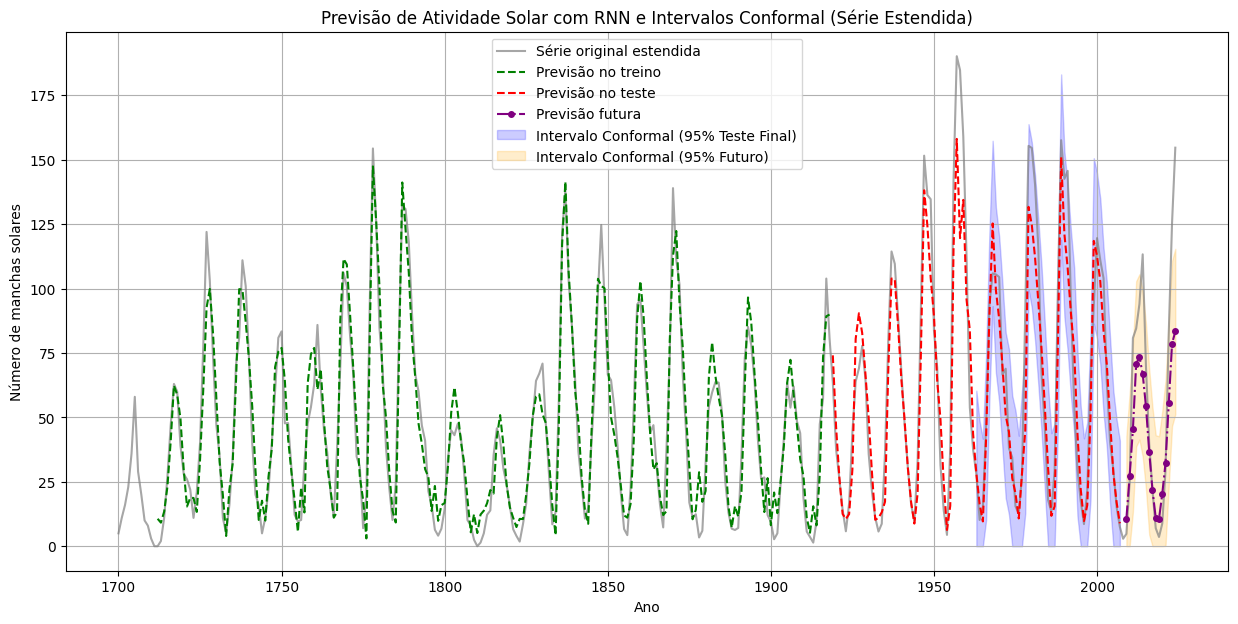

In [ ]:
import statsmodels.api as sm


original_df_for_plot = sm.datasets.sunspots.load_pandas().data
original_serie_for_plot = original_df_for_plot["SUNACTIVITY"].values.astype(np.float32)

real_future_years = df_aligned_future['Year'].values
real_future_sunspot_numbers = df_aligned_future['sunspot_number'].values

anos_extended = np.concatenate((anos, real_future_years))
serie_extended = np.concatenate((original_serie_for_plot, real_future_sunspot_numbers))

print(f"Shape of anos_extended: {anos_extended.shape}")
print(f"Shape of serie_extended: {serie_extended.shape}")

plt.figure(figsize=(15, 7))
plt.plot(anos_extended, serie_extended, label="Série original estendida", color='gray', alpha=0.7)

# Plotando as previsões de treino (um passo à frente)
plt.plot(anos_train, pred_train, label="Previsão no treino", color='green', linestyle='--')

# Plotando as previsões de teste (um passo à frente)
plt.plot(anos_test, pred_test, label="Previsão no teste", color='red', linestyle='--')

# Plotando as previsões futuras
plt.plot(future_anos, future_predictions, label="Previsão futura", color='purple', linestyle='-.', marker='o', markersize=4)

# Adicionando intervalos de predição conformal para o conjunto de teste final
plt.fill_between(
anos_test_final,
lower_bound,
upper_bound,
color='blue', alpha=0.2, label=f'Intervalo Conformal ({confidence_level*100:.0f}% Teste Final)'
)

# Adicionando intervalos de predição conformal para as previsões futuras
plt.fill_between(
future_anos,
lower_bound_future,
upper_bound_future,
color='orange', alpha=0.2, label=f'Intervalo Conformal ({confidence_level*100:.0f}% Futuro)'
)

plt.xlabel("Ano")
plt.ylabel("Número de manchas solares")
plt.title("Previsão de Atividade Solar com RNN e Intervalos Conformal (Série Estendida)")
plt.legend()
plt.grid(True)
plt.show()

Observa-se que os intervalos obtidos por meio da predição conformal foram capazes de incorporar parte da variabilidade que não foi capturada pelas previsões pontuais. Em particular, cerca de 95% dos valores observados ficaram contidos nos intervalos de predição, o que indica boa cobertura do método.

Para as previsões futuras, nota-se uma tendência de crescimento da atividade solar, em concordância com o comportamento observado nos valores reais. O erro quadrático médio das previsões futuras foi de aproximadamente 28. No entanto, é importante destacar que o processo preditivo foi realizado de forma recursiva, isto é, utilizando valores previamente preditos para gerar novas previsões. Esse procedimento tende a acumular incertezas ao longo do horizonte de previsão, aumentando a variabilidade e, consequentemente, a incerteza associada aos resultados obtidos.

# Conclusão
O modelo de rede neural recorrente (RNN) mostrou-se capaz de capturar adequadamente as relações temporais presentes na série de atividade solar. O desempenho obtido foi satisfatório, com erro quadrático médio de 10 no conjunto de treinamento e 16,5 no conjunto de teste, indicando boa capacidade preditiva, ainda que com perda de desempenho fora da amostra, como esperado.

Além disso, a predição conformal apresentou cobertura de 95%, evidenciando que os intervalos gerados foram capazes de incorporar boa parte da variabilidade não capturada pelas previsões pontuais. Para as previsões futuras, o erro quadrático médio foi de 28, valor superior ao observado no conjunto de teste. Esse resultado era esperado, uma vez que as previsões de longo prazo foram produzidas de forma recursiva, utilizando valores previamente preditos como entrada para novas predições, o que tende a propagar e acumular incertezas ao longo do horizonte de previsão.

Assim, conclui-se que o modelo proposto é adequado para este tipo de análise, pois permite identificar padrões não lineares na série temporal e explorar dependências ao longo de janelas de tempo maiores. Ainda assim, os resultados obtidos não esgotam as possibilidades de modelagem. Como continuidade, podem ser avaliadas arquiteturas mais complexas, com diferentes números de camadas ocultas e neurônios, bem como outros ajustes de hiperparâmetros. O modelo final apresentado foi definido com base em testes comparativos, dentre os quais essa configuração apresentou o melhor desempenho.